### Pre-Processing of the data

In [1]:
## Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# supress the warnings
import warnings
warnings.filterwarnings('ignore')


In [8]:
df = pd.read_csv(r"IT_Service_Ticket_SLA_Breach_Dataset.csv")

# Display first 5 rows
df.head()

,Unnamed: 0,ticket_priority,ticket_category,ticket_source,customer_tier,customer_previous_tickets,customer_previous_breaches,engineer_experience_years,number_of_engineers_assigned,estimated_resolution_hours,number_of_dependencies,system_impact,business_impact,hour_created,day_of_week,is_weekend,SLA_Breached
0,0,Medium,Incident,Portal,Standard,5,1,9.2,2,13.1,2.0,Medium,Low,19,Thursday,0,1
1,1,Medium,Incident,Portal,Premium,10,1,14.4,2,13.1,1.0,Low,Medium,4,Sunday,0,0
2,2,Medium,Incident,Email,Premium,9,1,14.9,2,5.9,NaN,Low,Medium,6,Sunday,1,0
3,3,Medium,Incident,Portal,Premium,4,1,13.5,1,3.4,0.0,Medium,Medium,13,Wednesday,0,0
4,4,Medium,Service Request,Portal,Standard,10,1,12.8,1,6.9,3.0,Low,Low,4,Thursday,0,0


In [6]:
# Check number of rows and columns
print("Dataset shape:", df.shape)

# List all columns
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (5050, 17)

Columns:
['Unnamed: 0', 'ticket_priority', 'ticket_category', 'ticket_source', 'customer_tier', 'customer_previous_tickets', 'customer_previous_breaches', 'engineer_experience_years', 'number_of_engineers_assigned', 'estimated_resolution_hours', 'number_of_dependencies', 'system_impact', 'business_impact', 'hour_created', 'day_of_week', 'is_weekend', 'SLA_Breached']


In [10]:
# Remove unnecessary index column created during CSV export
df = df.drop(columns=["Unnamed: 0"])

In [13]:
# Check missing values in each column
missing_values = df.isnull().sum()
missing_values

ticket_priority                   0
ticket_category                   0
ticket_source                     0
customer_tier                     0
customer_previous_tickets         0
customer_previous_breaches        0
engineer_experience_years       151
number_of_engineers_assigned      0
estimated_resolution_hours      150
number_of_dependencies          152
system_impact                     0
business_impact                   0
hour_created                      0
day_of_week                       0
is_weekend                        0
SLA_Breached                      0
dtype: int64

In [12]:
# Check number of rows and columns
print("Dataset shape:", df.shape)

# List all columns
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (5050, 16)

Columns:
['ticket_priority', 'ticket_category', 'ticket_source', 'customer_tier', 'customer_previous_tickets', 'customer_previous_breaches', 'engineer_experience_years', 'number_of_engineers_assigned', 'estimated_resolution_hours', 'number_of_dependencies', 'system_impact', 'business_impact', 'hour_created', 'day_of_week', 'is_weekend', 'SLA_Breached']


In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

ticket_priority                 0.000000
ticket_category                 0.000000
ticket_source                   0.000000
customer_tier                   0.000000
customer_previous_tickets       0.000000
customer_previous_breaches      0.000000
engineer_experience_years       2.990099
number_of_engineers_assigned    0.000000
estimated_resolution_hours      2.970297
number_of_dependencies          3.009901
system_impact                   0.000000
business_impact                 0.000000
hour_created                    0.000000
day_of_week                     0.000000
is_weekend                      0.000000
SLA_Breached                    0.000000
dtype: float64

In [14]:
# Separate independent features and target variable

X = df.drop("SLA_Breached", axis=1)
y = df["SLA_Breached"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5050, 15)
y shape: (5050,)


In [16]:
X.head(1)

,ticket_priority,ticket_category,ticket_source,customer_tier,customer_previous_tickets,customer_previous_breaches,engineer_experience_years,number_of_engineers_assigned,estimated_resolution_hours,number_of_dependencies,system_impact,business_impact,hour_created,day_of_week,is_weekend
0,Medium,Incident,Portal,Standard,5,1,9.2,2,13.1,2.0,Medium,Low,19,Thursday,0


In [18]:
y.head()

0    1
1    0
2    0
3    0
4    0
Name: SLA_Breached, dtype: int64

In [17]:
type(y)

pandas.core.series.Series

In [19]:
## Splitting Training and testing Data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4040, 15)
X_test : (1010, 15)
y_train: (4040,)
y_test : (1010,)


In [20]:
# Identify numerical and categorical columns

numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()

categorical_cols = X_train.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['customer_previous_tickets', 'customer_previous_breaches', 'engineer_experience_years', 'number_of_engineers_assigned', 'estimated_resolution_hours', 'number_of_dependencies', 'hour_created', 'is_weekend']

Categorical columns:
['ticket_priority', 'ticket_category', 'ticket_source', 'customer_tier', 'system_impact', 'business_impact', 'day_of_week']


### Imputing,Scaling numerical columns together
### Imputing, Encoding Categorical columns

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ))
    ]
)

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [23]:
## checking for missing values
# Check missing values in each column
missing_values = df.isnull().sum()
missing_values

ticket_priority                   0
ticket_category                   0
ticket_source                     0
customer_tier                     0
customer_previous_tickets         0
customer_previous_breaches        0
engineer_experience_years       151
number_of_engineers_assigned      0
estimated_resolution_hours      150
number_of_dependencies          152
system_impact                     0
business_impact                   0
hour_created                      0
day_of_week                       0
is_weekend                        0
SLA_Breached                      0
dtype: int64

## Creating baseline model "Logistic Regression"

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Create complete pipeline:
# 1. Preprocess the data
# 2. Train Logistic Regression

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [25]:
# training teh model

logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['customer_previous_tickets',
                                                   'customer_previous_breaches',
                                                   'engineer_experience_years',
                                                   'number_of_engineers_assigned',
                                                   'estimated_resolution_hours',
                                                   'number_of_dependencies',
                                                   'hour_created',
                                                   'is_weekend']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['ticket_priority',
                                                   'ticket_category',
                                                   'ticket_source',
                                                   'customer_tier',
                                                   'system_impact',
                                                   'business_impact',
                                                   'day_of_week'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

#### Training Data metrics

In [36]:
# Predict whether each ticket will breach the SLA on training data

y_train_pred = logistic_pipeline.predict(X_train)

print(y_train_pred[:10])

[0 1 1 0 0 0 0 0 0 0]


In [37]:
## Training Classification report

from sklearn.metrics import classification_report

classification_report_LR_train = classification_report(y_train, y_train_pred)

print(classification_report_LR_train)

              precision    recall  f1-score   support

           0       0.76      0.91      0.83      2783
           1       0.65      0.36      0.46      1257

    accuracy                           0.74      4040
   macro avg       0.70      0.63      0.64      4040
weighted avg       0.72      0.74      0.71      4040



### Testing Data metrics

In [26]:
# Predict whether each ticket will breach the SLA on testing data

y_pred = logistic_pipeline.predict(X_test)

print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 1]


In [27]:
# Predict probability of SLA breach

y_pred_proba = logistic_pipeline.predict_proba(X_test)[:, 1]

print(y_pred_proba[:10])

[0.09921665 0.20164854 0.20564069 0.18910778 0.3988665  0.34007926
 0.12409395 0.15747108 0.25277253 0.8928941 ]


In [29]:
from sklearn.metrics import ( accuracy_score, precision_score, recall_score,f1_score,roc_auc_score)

# Evaluate Logistic Regression

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Logistic Regression Results")
print("----------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Logistic Regression Results
----------------------------
Accuracy : 0.7446
Precision: 0.7077
Recall   : 0.4071
F1 Score : 0.5169
ROC-AUC  : 0.7738


In [33]:
from sklearn.metrics import classification_report

classification_report_LR = classification_report(y_test, y_pred)

print(classification_report_LR)

              precision    recall  f1-score   support

           0       0.75      0.92      0.83       671
           1       0.71      0.41      0.52       339

    accuracy                           0.74      1010
   macro avg       0.73      0.66      0.67      1010
weighted avg       0.74      0.74      0.72      1010



### Confusion Matrix

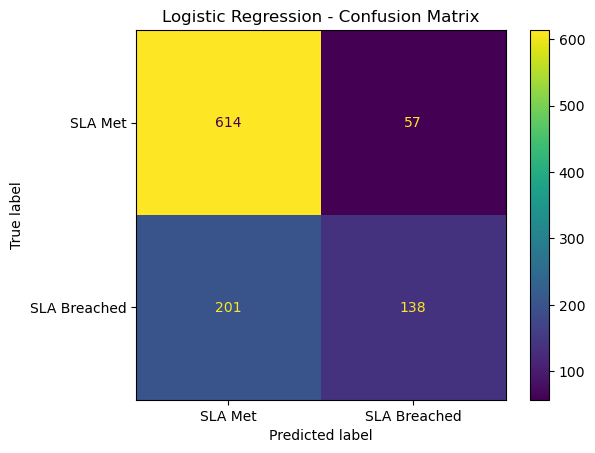

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["SLA Met", "SLA Breached"]
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

# Decision Tree

In [34]:
#Create the pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

# Decision Tree pipeline
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            random_state=42
        ))
    ]
)

In [35]:
 #Train Decision Tree

decision_tree_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['customer_previous_tickets',
                                                   'customer_previous_breaches',
                                                   'engineer_experience_years',
                                                   'number_of_engineers_assigned',
                                                   'estimated_resolution_hours',
                                                   'number_of_dependencies',
                                                   'hour_created',
                                                   'is_weekend']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['ticket_priority',
                                                   'ticket_category',
                                                   'ticket_source',
                                                   'customer_tier',
                                                   'system_impact',
                                                   'business_impact',
                                                   'day_of_week'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [41]:
#Predict

dt_y_test_pred = decision_tree_pipeline.predict(X_test)
print(dt_y_test_pred[:10])


[1 0 1 1 0 0 0 0 0 1]


#### Metrics on Training Data

In [38]:

# Predict class labels

dt_y_train_pred = decision_tree_pipeline.predict(X_train)
# Predict whether each ticket will breach the SLA on training data


print(dt_y_train_pred[:10])


[0 1 1 0 0 0 0 1 1 0]


In [39]:
## Training Classification report

classification_report_dt_train = classification_report(y_train, dt_y_train_pred)

print(classification_report_dt_train)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2783
           1       1.00      1.00      1.00      1257

    accuracy                           1.00      4040
   macro avg       1.00      1.00      1.00      4040
weighted avg       1.00      1.00      1.00      4040



In [42]:
## Training Classification report

classification_report_dt_test = classification_report(y_test, dt_y_test_pred)

print(classification_report_dt_test)

              precision    recall  f1-score   support

           0       0.74      0.73      0.74       671
           1       0.48      0.50      0.49       339

    accuracy                           0.65      1010
   macro avg       0.61      0.61      0.61      1010
weighted avg       0.65      0.65      0.65      1010



#### Observation:Training Metrics shown overfitting for Decision tree model and There is huge difference in report on unseen data. Hence tuning of teh model is required

In [44]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__max_depth': [2, 3, 4, 5, 6, 8, 10, 12, 15, None]
}

grid_search = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['customer_previous_tickets',
                                                                          'customer_previous_breaches',
                                                                          'engineer_experience_years',
                                                                          'number_of_engineers_assigned',
                                                                          'estimated_resolution_hours',
                                                                          'number_of_dep...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         ['ticket_priority',
                                                                          'ticket_category',
                                                                          'ticket_source',
                                                                          'customer_tier',
                                                                          'system_impact',
                                                                          'business_impact',
                                                                          'day_of_week'])])),
                                       ('model',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [2, 3, 4, 5, 6, 8, 10, 12, 15,
                                              None]},
             scoring='f1')

In [45]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

Best Parameters: {'model__max_depth': None}
Best CV F1 Score: 0.41781095039083366


In [48]:
dt_y_test_pred = grid_search.predict(X_test)

In [49]:
##Testing F1 score

f1 = f1_score(y_test, dt_y_test_pred)
print(f1)

0.4883720930232558


In [51]:
# the  Decision tree model requires hyperparameter tuning further

param_grid = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [3, 5,6, 7, 10, None],
    'model__min_samples_split': [5, 10, 15],
    'model__min_samples_leaf': [3, 5, 10]
}

grid_search = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

Best Parameters: {'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__min_samples_split': 5}
Best CV F1 Score: 0.43737840464899247


In [54]:
# predicting the Y_test based on the best estimators

best_dt_model = grid_search.best_estimator_

y_test_pred = best_dt_model.predict(X_test)

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.74      0.78      0.76       671
           1       0.50      0.45      0.47       339

    accuracy                           0.67      1010
   macro avg       0.62      0.61      0.61      1010
weighted avg       0.66      0.67      0.66      1010



### After CV F1- scores are .76, .47 for class 0, class 1 respecively

# Random Forest Classifier

### Create Random Forest pipeline

In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            random_state=42
        ))
    ]
)

In [57]:
random_forest_pipeline.fit(X_train, y_train)
y_train_pred_rf = random_forest_pipeline.predict(X_train)
y_test_pred_rf = random_forest_pipeline.predict(X_test)


In [58]:
# Training classification report

from sklearn.metrics import classification_report

print(classification_report(y_train, y_train_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2783
           1       1.00      1.00      1.00      1257

    accuracy                           1.00      4040
   macro avg       1.00      1.00      1.00      4040
weighted avg       1.00      1.00      1.00      4040



In [59]:
# Testing classification report

print(classification_report(y_test, y_test_pred_rf))

              precision    recall  f1-score   support

           0       0.72      0.93      0.81       671
           1       0.69      0.30      0.42       339

    accuracy                           0.72      1010
   macro avg       0.71      0.61      0.62      1010
weighted avg       0.71      0.72      0.68      1010



In [60]:
from sklearn.metrics import roc_auc_score

y_test_proba_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_test_proba_rf)

print("Test ROC-AUC:", roc_auc_rf)

Test ROC-AUC: 0.7325723505180927


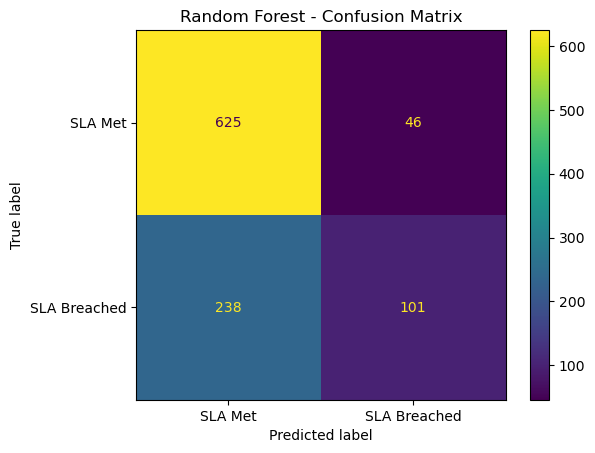

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["SLA Met", "SLA Breached"]
)

disp.plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

### Tuning the parameters to improve the performance of the models

In [65]:
param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 6, None],
    'model__max_features': ['sqrt', 'log2', None],
    'model__criterion': ['gini', 'entropy']
}

from sklearn.model_selection import GridSearchCV

grid_search_rf = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

print("Best Parameters:", grid_search_rf.best_params_)
print("Best CV F1 Score:", grid_search_rf.best_score_)

Best Parameters: {'model__criterion': 'gini', 'model__max_depth': None, 'model__max_features': None, 'model__n_estimators': 100}
Best CV F1 Score: 0.40148043618277995


In [68]:
## Appying teh best parameters to Test DataSet

best_rf_model = grid_search_rf.best_estimator_
y_test_pred_rf = best_rf_model.predict(X_test)

print(classification_report(y_test, y_test_pred_rf))

              precision    recall  f1-score   support

           0       0.74      0.91      0.81       671
           1       0.67      0.36      0.47       339

    accuracy                           0.72      1010
   macro avg       0.70      0.63      0.64      1010
weighted avg       0.71      0.72      0.70      1010



### So tuning did improve Class 1 F1 from 0.42 → 0.47 keeping the accurancy same

# AdaBoost Clasifier

In [71]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.pipeline import Pipeline

adaboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", AdaBoostClassifier(
            random_state=42
        ))
    ]
)
adaboost_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['customer_previous_tickets',
                                                   'customer_previous_breaches',
                                                   'engineer_experience_years',
                                                   'number_of_engineers_assigned',
                                                   'estimated_resolution_hours',
                                                   'number_of_dependencies',
                                                   'hour_created',
                                                   'is_weekend']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['ticket_priority',
                                                   'ticket_category',
                                                   'ticket_source',
                                                   'customer_tier',
                                                   'system_impact',
                                                   'business_impact',
                                                   'day_of_week'])])),
                ('model', AdaBoostClassifier(random_state=42))])

### Evaluate

In [72]:
y_test_pred_ada = adaboost_pipeline.predict(X_test)

print(classification_report(y_test, y_test_pred_ada))

              precision    recall  f1-score   support

           0       0.75      0.91      0.82       671
           1       0.69      0.39      0.50       339

    accuracy                           0.74      1010
   macro avg       0.72      0.65      0.66      1010
weighted avg       0.73      0.74      0.71      1010



#### ROC-AUC

In [73]:
y_test_proba_ada = adaboost_pipeline.predict_proba(X_test)[:, 1]

roc_auc_ada = roc_auc_score(y_test, y_test_proba_ada)

print("Test ROC-AUC:", roc_auc_ada)

Test ROC-AUC: 0.7603277809283902


In [76]:
# Tunig teh 

param_grid_ada = {
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.01, 0.1, 0.5, 1.0]
}


grid_search_ada = GridSearchCV(
    estimator=adaboost_pipeline,
    param_grid=param_grid_ada,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search_ada.fit(X_train, y_train)

print("Best Parameters:", grid_search_ada.best_params_)
print("Best CV F1 Score:", grid_search_ada.best_score_)

Best Parameters: {'model__learning_rate': 1.0, 'model__n_estimators': 200}
Best CV F1 Score: 0.44976469500387983


In [78]:
best_ada_model = grid_search_ada.best_estimator_

y_test_pred_ada = best_ada_model.predict(X_test)

print(classification_report(y_test, y_test_pred_ada))

              precision    recall  f1-score   support

           0       0.75      0.91      0.82       671
           1       0.68      0.40      0.50       339

    accuracy                           0.73      1010
   macro avg       0.71      0.65      0.66      1010
weighted avg       0.73      0.73      0.71      1010



### project conclusion
#### The classification experiments show that ensemble methods can provide better generalization than a single Decision Tree. Among the models evaluated, AdaBoost achieved the best overall test performance, with 73% accuracy and a macro F1-score of 0.66. It also achieved the highest F1-score for the minority Class 1 at 0.50. Random Forest provided the second-best overall performance, while the Decision Tree performed comparatively weaker and showed signs of overfitting. Therefore, AdaBoost would be selected as the preferred model among the evaluated approaches. However, the relatively low recall and F1-score for Class 1 indicate that further improvements would be required before deploying the model in a production environment.

In [79]:
import joblib

joblib.dump(best_ada_model, "adaboost_classification_model.pkl")

['adaboost_classification_model.pkl']